In [ ]:
!pip install scikit-learn spacy
!python -m spacy download fr_core_news_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 81.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
import pandas as pd
import spacy
from sklearn.feature_extraction.text import TfidfVectorizer
import io
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# CHARGEMENT DU DATASET RÉEL
# ==============================
# Upload le fichier CSV
from google.colab import files
uploaded = files.upload()


df_offres = pd.read_csv(io.BytesIO(list(uploaded.values())[0]))

print(f" Dataset chargé : {df_offres.shape[0]} offres, {df_offres.shape[1]} colonnes")
print(f" Colonnes : {list(df_offres.columns)}")
df_offres.head(3)

Saving dataset_dm.csv to dataset_dm (1).csv
 Dataset chargé : 2775 offres, 11 colonnes
 Colonnes : ['title', 'company', 'location', 'sector', 'description', 'required_skills', 'required_education', 'required_experience', 'required_languages', 'contract_type', 'posted_date']


,title,company,location,sector,description,required_skills,required_education,required_experience,required_languages,contract_type,posted_date
0,Support Technique Client mobile (N2) (H/F) | ...,NaN,Maroc,Réseaux,Offre d'emploi Support Technique Client mobile...,Nos atouts chez BTechnologie : • Bénéficiez d’...,Nos atouts chez BTechnologie : • Bénéficiez d’...,.image-grid .image-grid img .btn-custom .btn-c...,NaN,NaN,2026-04-11
1,Responsable opérationnel franchise | Casablanc...,NaN,Maroc,Réseaux,Offre d'emploi Responsable opérationnel franch...,Vous possédez d'excellentes compétences en ges...,"Un diplôme de niveau Bac +4 est requis, idéale...",Vos objectifs principaux seront d'assurer l'ex...,NaN,NaN,2026-04-11
2,Ingénieur SecOps PAM | Casablanca (Maroc),NaN,Maroc,Réseaux,Offre d'emploi Ingénieur SecOps PAM - Casablan...,l’ingénieur SecOps IGA interviendra sur les po...,cabinet d’accompagnement à la transformation n...,Avec plus de 30 ans d’expérience dans le domai...,"Langues : Anglais courant, indispensable pour ...",NaN,2026-04-11


In [ ]:

# CRÉATION DU TEXTE COMBINÉ
# ==============================
# On combine les colonnes importantes en un seul texte par offre

def combiner_texte(row):
    champs = [
        str(row.get("title", "")),
        str(row.get("required_skills", "")),
        str(row.get("required_education", "")),
        str(row.get("required_experience", "")),
        str(row.get("description", ""))[:300]  # on limite la description
    ]
    return " ".join([c for c in champs if c != "nan"])

df_offres["texte_combine"] = df_offres.apply(combiner_texte, axis=1)

print(" Exemple de texte combiné :")
print(df_offres["texte_combine"].iloc[0])

 Exemple de texte combiné :
Support Technique Client  mobile (N2) (H/F) | Rabat (Maroc) Nos atouts chez BTechnologie : • Bénéficiez d’un accompagnement personnalisé dès votre 1er jour d’arrivée par notre équipe Onboarding et votre futur Manager (accueil au sein de nos locaux à Rabat, journée d’onboarding, petit-déjeuner convivial). • Développez vos compétences techniques, fonctionnelles ou de management, grâce au catalogues de formations Accenture et à l’aide de nos Practice Managers et de leurs communautés. • Faîtes évoluer votre carrière grâce à notre politique de mobilité. Nos atouts chez BTechnologie : • Bénéficiez d’un accompagnement personnalisé dès votre 1er jour d’arrivée par notre équipe Onboarding et votre futur Manager (accueil au sein de nos locaux à Rabat, journée d’onboarding, petit-déjeuner convivial). • Développez vos compétences techniques, fonctionnelles ou de management, grâce au catalogues de formations Accenture et à l’aide de nos Practice Managers et de leurs comm

In [ ]:
# ÉTAPE 3 — PREPROCESSING NLP
# ==============================
nlp = spacy.load("fr_core_news_sm")

def nettoyer_texte(texte):
    doc = nlp(texte.lower())
    tokens = [
        token.lemma_
        for token in doc
        if not token.is_stop
        and not token.is_punct
        and len(token.text) > 2
        and token.is_alpha  # garde uniquement les vrais mots
    ]
    return " ".join(tokens)

print(" Nettoyage en cours... (peut prendre 1-2 minutes)")
df_offres["texte_clean"] = df_offres["texte_combine"].apply(nettoyer_texte)

print("\n Nettoyage terminé !")
print("\n--- Avant ---")
print(df_offres["texte_combine"].iloc[0][:200])
print("\n--- Après ---")
print(df_offres["texte_clean"].iloc[0])

 Nettoyage en cours... (peut prendre 1-2 minutes)

 Nettoyage terminé !

--- Avant ---
Support Technique Client  mobile (N2) (H/F) | Rabat (Maroc) Nos atouts chez BTechnologie : • Bénéficiez d’un accompagnement personnalisé dès votre 1er jour d’arrivée par notre équipe Onboarding et vot

--- Après ---
support technique client mobile rabat maroc atout btechnologie bénéficiez accompagnement personnaliser jour arriver équipe onboarding futur manager accueil sein local rabat journée onboarding convivial développer compétence technique fonctionnel management grâce catalogue formation accentur aide practice manager communauté faîte évoluer carrière grâce politique mobilité atout btechnologie bénéficiez accompagnement personnaliser jour arriver équipe onboarding futur manager accueil sein local rabat journée onboarding convivial développer compétence technique fonctionnel management grâce catalogue formation accentur aide practice manager communauté faîte évoluer carrière grâce politique mobi

In [ ]:

# CELLULE 5 — SUPPRESSION DOUBLONS
# ==============================

print(f"Offres avant suppression : {len(df_offres)}")

df_offres = df_offres.drop_duplicates().reset_index(drop=True)

print(f"Offres après suppression : {len(df_offres)}")
print(f" Doublons supprimés : {2775 - len(df_offres)}")

Offres avant suppression : 2775
Offres après suppression : 2768
 Doublons supprimés : 7


In [ ]:

#  CV UTILISATEUR
# (formulaire rempli par l'utilisateur)
# ==============================
print(" Remplis les informations de ton CV :\n")

nom        = input("Ton nom : ")
competences = input("Tes compétences (ex: Python, SQL, NLP...) : ")
experience  = input("Ton expérience (ex: 3 ans data science) : ")
formation   = input("Ta formation (ex: Bac+5 école ingénieur) : ")

cv_utilisateur = {
    "nom": nom,
    "texte": f"""
    {competences}.
    {experience}.
    {formation}.
    """
}

cv_clean = nettoyer_texte(cv_utilisateur["texte"])
print(f"\n CV de {nom} nettoyé !")
print(f" Texte nettoyé : {cv_clean}")

 Remplis les informations de ton CV :

Ton nom : Youssef
Tes compétences (ex: Python, SQL, NLP...) : sql
Ton expérience (ex: 3 ans data science) : 3ans
Ta formation (ex: Bac+5 école ingénieur) : bac+5

 CV de Youssef nettoyé !
 Texte nettoyé : sql


In [ ]:
#  VECTORISATION TF-IDF
# ==============================
# On combine CV + toutes les offres pour vectoriser ensemble
tous_textes = [cv_clean] + list(df_offres["texte_clean"])

vectorizer = TfidfVectorizer(max_features=500)
matrice_tfidf = vectorizer.fit_transform(tous_textes)

# Séparer CV et offres
vecteur_cv      = matrice_tfidf[0]   # le CV = ligne 0
vecteurs_offres = matrice_tfidf[1:]  # les offres = reste

print(" Vectorisation TF-IDF terminée !")
print(f" Vocabulaire          : {len(vectorizer.get_feature_names_out())} mots")
print(f" Forme matrice offres : {vecteurs_offres.shape}")
print(f" Forme vecteur CV     : {vecteur_cv.shape}")

 Vectorisation TF-IDF terminée !
 Vocabulaire          : 500 mots
 Forme matrice offres : (2768, 500)
 Forme vecteur CV     : (1, 500)


In [ ]:
#  SIMILARITÉ COSINUS
# ==============================
# Calcul des scores entre le CV et TOUTES les offres
scores = cosine_similarity(vecteur_cv, vecteurs_offres)[0]

# Ajouter les scores au DataFrame
df_offres["score_matching"] = scores

# Trier par score décroissant
df_resultats = df_offres[["title", "sector", "required_skills",
                           "contract_type", "score_matching"]]\
               .sort_values("score_matching", ascending=False)

print("TOP 10 offres les plus compatibles avec ton CV :\n")
print(df_resultats.head(10).to_string(index=False))

print(f"\n Score max   : {scores.max():.4f}")
print(f" Score min   : {scores.min():.4f}")
print(f"Score moyen : {scores.mean():.4f}")

TOP 10 offres les plus compatibles avec ton CV :

                                                                                                                  title     sector                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                      required_skills  contract_type  score_matching
                                                                             Barman Palace & Villas | Marrakech (Maroc) Hôtellerie                                                                                                                                                             

 Réduction des dimensions...
dimensions réduites : (2768, 50)
 Calcul du coude...


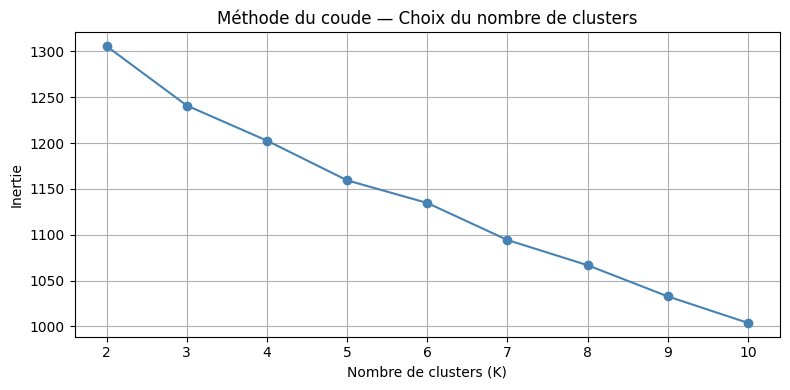

In [ ]:

# CLUSTERING K-MEANS
# ==============================

# ÉTAPE 1 — Réduire dimensions (50 au lieu de 500)
print(" Réduction des dimensions...")
svd = TruncatedSVD(n_components=50, random_state=42)
vecteurs_reduits = svd.fit_transform(vecteurs_offres)
print(f"dimensions réduites : {vecteurs_reduits.shape}")

# ÉTAPE 2 — Méthode du coude sur vecteurs réduits
print(" Calcul du coude...")
inerties = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(vecteurs_reduits)
    inerties.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inerties, marker='o', color='steelblue')
plt.title("Méthode du coude — Choix du nombre de clusters")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.xticks(K_range)
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
#  Appliquer K-Means sur vecteurs réduits
K_OPTIMAL = 6
km_final = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df_offres["cluster"] = km_final.fit_predict(vecteurs_reduits)

print(f"Clustering terminé avec K={K_OPTIMAL}")
print("\n Répartition des offres par cluster :")
print(df_offres["cluster"].value_counts().sort_index())

print("\n Exemples de titres par cluster :")
for c in range(K_OPTIMAL):
    titres = df_offres[df_offres["cluster"] == c]["title"].head(3).tolist()
    print(f"\n  Cluster {c} : {titres}")

Clustering terminé avec K=6

 Répartition des offres par cluster :
cluster
0    479
1    296
2     78
3    731
4    943
5    241
Name: count, dtype: int64

 Exemples de titres par cluster :

  Cluster 0 : ['Support Technique Client  mobile (N2) (H/F) | Rabat (Maroc)', 'IT Support Specialist | Rabat (Maroc)', 'Ingénieur Optimisation QoS Mobile | Rabat (Maroc)']

  Cluster 1 : ['Chargé de clientèle hispanophone/anglophone | Casablanca (Maroc)', 'Technico-commercial | Salé (Maroc)', 'Technico-commercial | Fès (Maroc)']

  Cluster 2 : ['ANIMATEUR TPE (H/F) | Rabat (Maroc)', 'Chargé de Portefeuille ALKIFAH | Rabat (Maroc)', 'Chargé de Portefeuille Bir Rami | Kénitra (Maroc)']

  Cluster 3 : ['Superviseur Caisse H/F | Béni Mellal (Maroc)', 'Finance Business Partner | Skhirat (Maroc)', 'Chargé(e) de Facturation & Livairson | Agadir (Maroc)']

  Cluster 4 : ['Responsable opérationnel franchise | Casablanca (Maroc)', 'Ingénieur SecOps PAM | Casablanca (Maroc)', 'Administrateur Systèmes, Réseaux

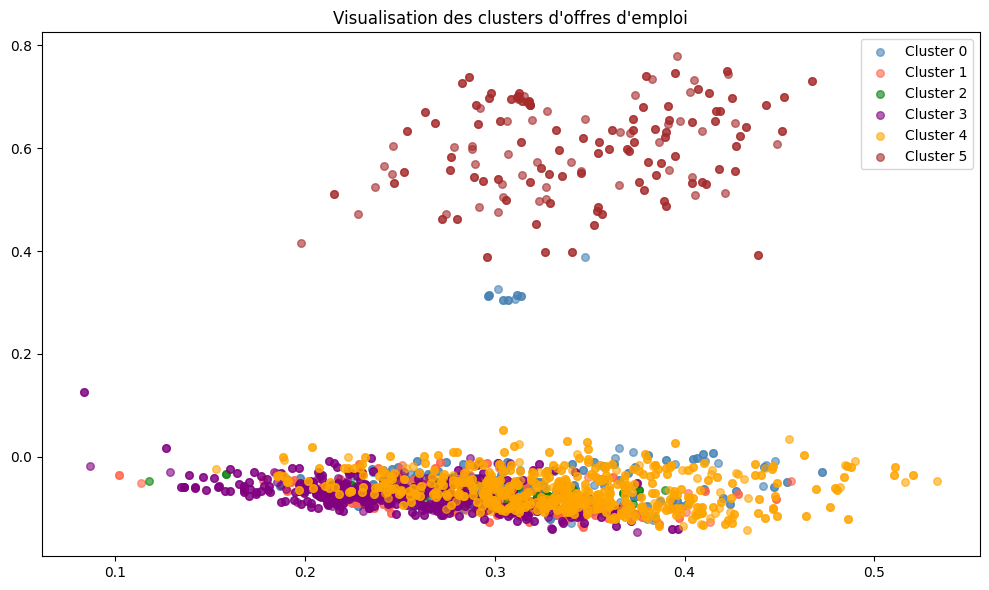

 Visualisation terminée !


In [ ]:
# Visualisation 2D des clusters
svd_2d = TruncatedSVD(n_components=2, random_state=42)
coords = svd_2d.fit_transform(vecteurs_reduits)

colors = ['steelblue','tomato','green','purple','orange','brown']
plt.figure(figsize=(10, 6))

for c in range(K_OPTIMAL):
    mask = df_offres["cluster"] == c
    plt.scatter(
        coords[mask, 0],
        coords[mask, 1],
        label=f"Cluster {c}",
        alpha=0.6,
        s=30,
        color=colors[c]
    )

plt.title("Visualisation des clusters d'offres d'emploi")
plt.legend()
plt.tight_layout()
plt.show()
print(" Visualisation terminée !")

In [ ]:

#  FONCTION MATCHING FINALE
# ==============================
def match_cv_offres_v2(texte_cv, top_n=5):
    """
    Fonction principale de matching.
    Entrée  : texte brut du CV (string)
    Sortie  : liste des top N offres compatibles (dict)
    → Appelée directement par l'API Django (Personne 3)
    """
    #  Nettoyer le CV
    cv_clean = nettoyer_texte(texte_cv)

    #  Vectoriser
    vecteur_cv = vectorizer.transform([cv_clean])

    #  Similarité cosinus contre toutes les offres
    scores = cosine_similarity(vecteur_cv, vecteurs_offres)[0]

    #  Ajouter scores
    df_temp = df_offres.copy()
    df_temp["score"] = (scores * 100).round(1)

    # Retourner Top N en format JSON
    top = df_temp.nlargest(top_n, "score")[
        ["title", "sector", "required_skills",
         "contract_type", "cluster", "score"]
    ]
    return top.to_dict(orient="records")


# TESTS FINAUX
print("=" * 60)
print(" TEST 1 — Profil Data Science")
print("=" * 60)
cv_data = """
Ingénieur data science Python machine learning scikit-learn
pandas numpy SQL NLP traitement données modélisation
statistiques deep learning Bac+5 école ingénieur
"""
resultats = match_cv_offres_v2(cv_data, top_n=5)
for i, offre in enumerate(resultats, 1):
    print(f"{i}. {offre['title']}")
    print(f"   Secteur : {offre['sector']}")
    print(f"   Score   : {offre['score']}%")
    print()

print("=" * 60)
print(" TEST 2 — Profil Réseaux")
print("=" * 60)
cv_reseau = """
Ingénieur réseaux sécurité informatique administration
systèmes Linux Windows virtualisation VMware Cisco
firewall VPN infrastructure serveurs 5 ans expérience
"""
resultats2 = match_cv_offres_v2(cv_reseau, top_n=5)
for i, offre in enumerate(resultats2, 1):
    print(f"{i}. {offre['title']}")
    print(f"   Secteur : {offre['sector']}")
    print(f"   Score   : {offre['score']}%")
    print()

 TEST 1 — Profil Data Science
1. Data Scientist / Ingénieur IA | Casablanca (Maroc)
   Secteur : Python
   Score   : 51.3%

2. Data Scientist / Ingénieur IA | Casablanca (Maroc)
   Secteur : Python
   Score   : 51.3%

3. Data Engineer Expérimenté (Data Platform) | Rabat (Maroc)
   Secteur : Data
   Score   : 48.5%

4. Data Engineer Expérimenté (Data Platform) | Rabat (Maroc)
   Secteur : Big Data
   Score   : 48.5%

5. Data Ops Sénior – Data Platform | Rabat (Maroc)
   Secteur : Python
   Score   : 46.0%

 TEST 2 — Profil Réseaux
1. Ingénieur Réseaux & Systèmes | Sala al Jadida (Maroc)
   Secteur : Python
   Score   : 55.8%

2. Ingénieur Réseaux & Systèmes | Sala al Jadida (Maroc)
   Secteur : Python
   Score   : 55.8%

3. Administrateur Réseau et système | Mohammedia (Maroc)
   Secteur : Communication
   Score   : 54.3%

4. Administrateur Réseau et système | Mohammedia (Maroc)
   Secteur : Systèmes
   Score   : 54.3%

5. Ingénieur Systèmes Embarqués | Rabat (Maroc)
   Secteur : Ingéni

In [ ]:
#  SAUVEGARDE MODÈLES
# ==============================
import pickle
with open("vectorizer_tfidf.pkl", "wb") as f:
    pickle.dump(vectorizer, f)

with open("kmeans_model.pkl", "wb") as f:
    pickle.dump(km_final, f)

with open("offres_clean.pkl", "wb") as f:
    pickle.dump(df_offres[["title", "sector", "cluster",
                            "texte_clean", "required_skills",
                            "contract_type"]], f)

print(" Modèles sauvegardés !")
print("  → vectorizer_tfidf.pkl")
print("  → kmeans_model.pkl")
print("  → offres_clean.pkl")

 Modèles sauvegardés !
  → vectorizer_tfidf.pkl
  → kmeans_model.pkl
  → offres_clean.pkl
